In [1]:
%pip install matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [190]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 7.42]

In [203]:
L, N, rho0 = 1, 50, 1
h = L/N
x = np.linspace(0, L, N+1)
x_int = x[1:-1]
sin_color, num_color = "#5C7AFF", "#FF8200"

In [143]:
def sin_charge(x: float) -> tuple[float, float]:
    L, rho0, epsilon0 = 1, 1, 1
    rho = (rho0 / epsilon0) * (L / np.pi)**2 * np.sin(np.pi * x / L)
    E = -(rho0 / epsilon0) * (L / np.pi) * np.cos(np.pi * x / L)
    
    return rho, E

rho_anal, E_anal = sin_charge(x_int)

In [250]:
def diff_sin(Va: float, Vb: float, N: float, x: float, h: float, rho0: float = 1) -> float:
    Va, Vb = 0, 0
    diag_main = np.ones(N-1) * 2.0 / h**2
    diag_off = np.ones(N-2) * (-1.0) / h**2
    
    A = np.diag(diag_main) + np.diag(diag_off, k=1) + np.diag(diag_off, k=-1)
    b = rho0 * np.sin(np.pi * x / L)
    b[0] += Va / h**2
    b[-1] += Vb / h**2

    phi_internal = np.linalg.solve(A, b)

    return phi_internal

def electric_field(x_int: list[float], phi_int: list[float]) -> list[float]:
    E = np.zeros(len(x_int))
    k = -1/(2*h)
    for i in range(1, len(x_int)-1):
        E[i] = (phi_int[i+1] - phi_int[i-1]) * k
    
    E[0] = (phi_int[1] - phi_int[0]) * 2 * k
    E[-1] = (phi_int[-1] - phi_int[-2]) * 2 * k

    return E
    
phi_int = diff_sin(Va=Va, Vb=Vb, N=50, x=x_int, h=h)
E = electric_field(x_int=x_int, phi_int=phi_int)

In [214]:
print(max(abs(phi_int - sin_charge(x_int)[0])))
print(max(abs(E-E_anal)))

3.3339914100094514e-05
0.0007324251872328214


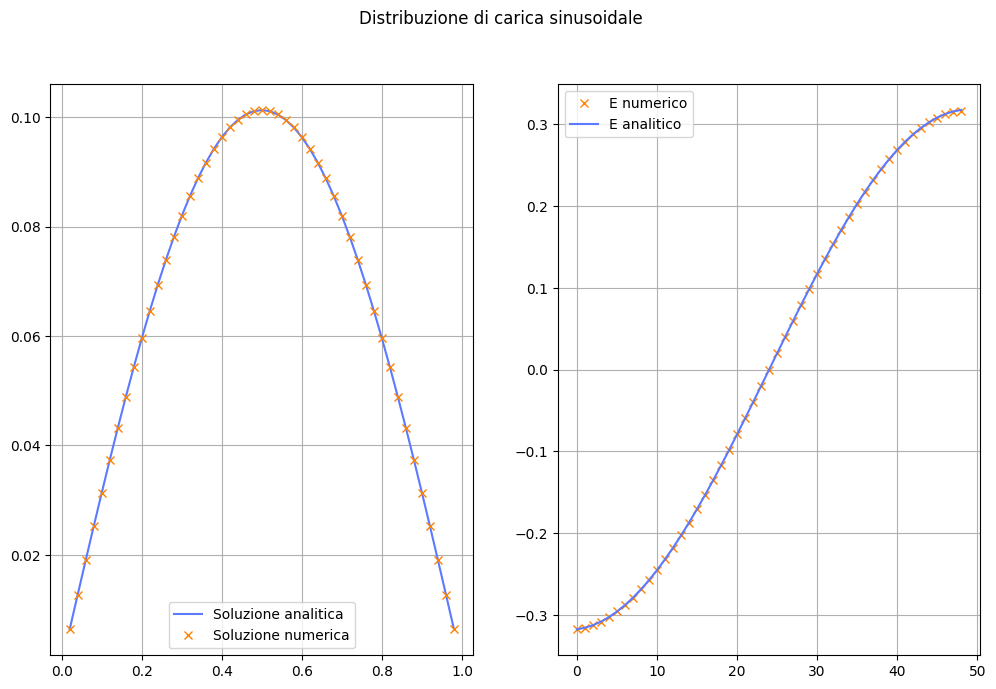

In [252]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(x_int, rho_anal, color=sin_color, label="Soluzione analitica")
ax1.plot(x_int, phi_int, "x", color=num_color, label="Soluzione numerica")
ax1.grid(True)
ax1.legend()
plt.suptitle("Distribuzione di carica sinusoidale")
ax2.plot(E, "x", color=num_color, label="E numerico")
ax2.plot(E_anal, color=sin_color, label="E analitico")
ax2.legend()
ax2.grid(True)
plt.show()

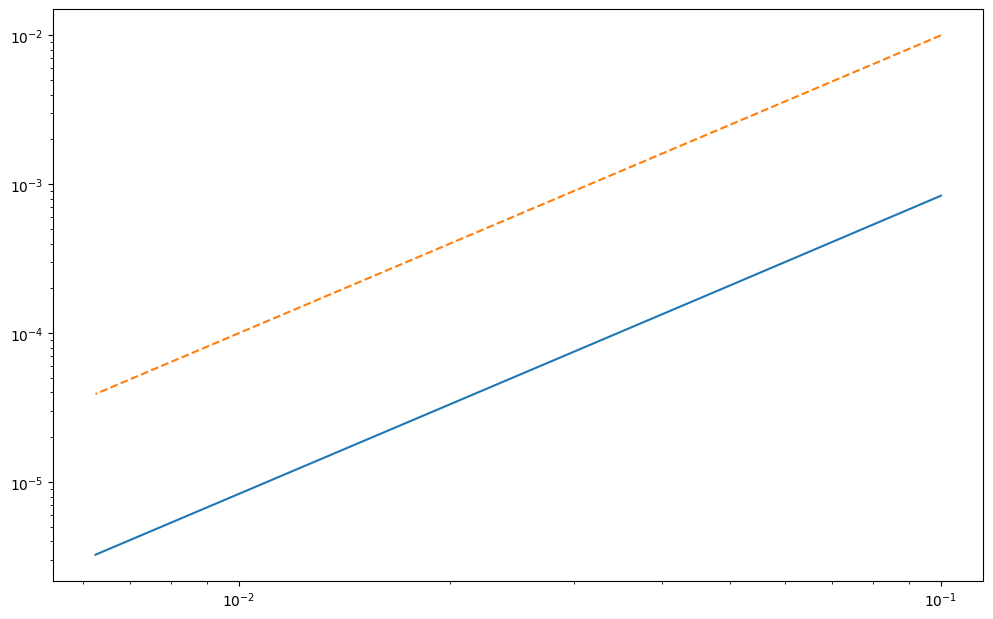

In [265]:
Ns = np.array([10, 20, 40, 80, 160])
hs = L / Ns
errs = []

for i in range(len(Ns)):
    xs = np.linspace(0, L, Ns[i]+1)
    xs_int = xs[1:-1]
    rho_a, _ = sin_charge(xs_int)
    rho_n = diff_sin(Va=Va, Vb=Vb, N=Ns[i], x=xs_int, h=hs[i])
    errs.append(np.max(np.abs(rho_a - rho_n)))

plt.loglog(hs, errs)
plt.plot(hs, hs**2, "--")
plt.show()